Solving Potential (a)...
Eigenvalues for Potential (a): [np.float64(-20.993935066730398), np.float64(-14.275774078192585), np.float64(-5.232339565751586)]

Solving Potential (b): Harmonic Oscillator...
Eigenvalues for QHO: [np.float64(1.0000000000865785), np.float64(3.0000000039996686), np.float64(5.000000090467316)]
Theoretical Values: [1, 3, 5]


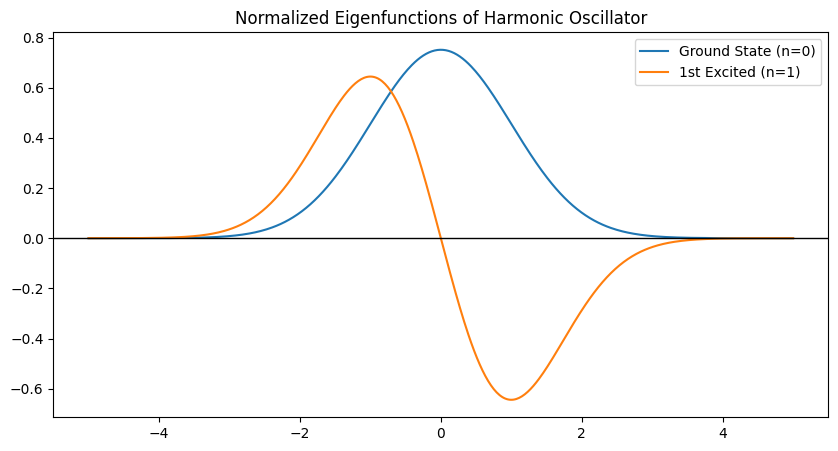

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# SHARED UTILITY FUNCTIONS
# =============================================================================

def rk4(f, x, y, E, h):
    """4th-order Runge-Kutta step for the system of ODEs."""
    k1 = h * f(x, y, E)
    k2 = h * f(x + h/2, y + k1/2, E)
    k3 = h * f(x + h/2, y + k2/2, E)
    k4 = h * f(x + h, y + k3, E)
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

def simp13(f, h):
    """Simpson's 1/3 rule for normalization."""
    return np.sqrt(h/3 * (f[0]**2 + f[-1]**2 + 4*np.sum(f[1:-1:2]**2) + 2*np.sum(f[2:-1:2]**2)))

def secant(E1, E2, score_func, eps=1e-5, maxiter=50):
    """Secant method to find the energy eigenvalue where the 'score' hits zero."""
    for i in range(maxiter):
        f1 = score_func(E1)
        f2 = score_func(E2)
        if abs(f2 - f1) < 1e-12: break
        E3 = E2 - f2 * (E2 - E1) / (f2 - f1)
        if abs(E3 - E2) < eps:
            return E3
        E1, E2 = E2, E3
    return E2

# =============================================================================
# QUESTION 1(a): Asymmetric Potential Well
# V(x) = -V0(1-x^3)/2 for |x| <= 1, else 0. V0 = 40.
# =============================================================================

V0 = 40.0
L0 = 1.0

def pot_a(x):
    if abs(x) <= L0:
        return -V0 * (1 - x**3) / 2
    return 0.0

def odefun_a(x, y, E):
    """Schrodinger Eq: d2psi/dx2 = (V - E)psi. (Using units where 2m/hbar^2 = 1)"""
    psi, phi = y # y[0] is psi, y[1] is dpsi/dx
    dpsi = phi
    dphi = (pot_a(x) - E) * psi
    return np.array([dpsi, dphi])

def score_a(E):
    """Integrates from x=-2 to x=2. Returns final psi value (should be 0)."""
    x, xf = -2.0, 2.0
    h = 0.01
    y = np.array([0.0, 1e-3]) # Boundary condition: psi(-inf)=0, dpsi/dx=small
    while x < xf:
        y = rk4(odefun_a, x, y, E, h)
        x += h
    return y[0]

# Finding first few eigenvalues for Potential A
print("Solving Potential (a)...")
energies_a = []
for guess in np.arange(-35, 0, 5):
    E_eigen = secant(guess, guess+1, score_a)
    if not any(abs(E_eigen - e) < 0.1 for e in energies_a) and E_eigen < 0:
        energies_a.append(E_eigen)

print(f"Eigenvalues for Potential (a): {sorted(energies_a)}")

# =============================================================================
# QUESTION 1(b): Quantum Harmonic Oscillator
# V(x) = x^2
# =============================================================================

def pot_b(x):
    return x**2

def odefun_b(x, y, E):
    psi, phi = y
    return np.array([phi, (pot_b(x) - E) * psi])

def score_b(E):
    """Shooting for Harmonic Oscillator."""
    x, xf = -5.0, 5.0 # Boundary approximations for infinity
    h = 0.01
    y = np.array([0.0, 1e-5]) 
    while x < xf:
        y = rk4(odefun_b, x, y, E, h)
        x += h
    return y[0]

# Finding first few eigenvalues for QHO (Theory: 1, 3, 5, 7...)
print("\nSolving Potential (b): Harmonic Oscillator...")
eigen_b = []
for guess in [0.5, 2.5, 4.5]:
    val = secant(guess, guess+0.5, score_b)
    eigen_b.append(val)

print(f"Eigenvalues for QHO: {eigen_b}")
print("Theoretical Values: [1, 3, 5]")

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_wavefunction(odefun, E, label, x_range):
    x_vals = np.linspace(x_range[0], x_range[1], 500)
    h = x_vals[1] - x_vals[0]
    y = np.array([0.0, 1e-5])
    psi_vals = []
    for x in x_vals:
        psi_vals.append(y[0])
        y = rk4(odefun, x, y, E, h)
    
    # Normalization
    psi_arr = np.array(psi_vals)
    norm = simp13(psi_arr, h)
    plt.plot(x_vals, psi_arr/norm, label=label)

plt.figure(figsize=(10, 5))
plot_wavefunction(odefun_b, eigen_b[0], "Ground State (n=0)", (-5, 5))
plot_wavefunction(odefun_b, eigen_b[1], "1st Excited (n=1)", (-5, 5))
plt.title("Normalized Eigenfunctions of Harmonic Oscillator")
plt.axhline(0, color='black', lw=1)
plt.legend()
plt.show()